In [1]:
import numpy as np
import matplotlib.pyplot as plt

import mne
import scipy

from mne.viz import circular_layout
from mne_connectivity import spectral_connectivity_epochs
from mne_connectivity.viz import plot_connectivity_circle

from mne.minimum_norm import make_inverse_operator, apply_inverse_raw, source_band_induced_power, apply_inverse_epochs,compute_source_psd, compute_source_psd_epochs

In [2]:
dic = {
'PASP001':'s15363',
'PASP002':'s15508',
'PASP004':'15763',
'PASP014':'17105',
'PASP017':'15913',
'PASP019':'16850',
'PASP020':'17053',
'PASP021':'16803',
'PASP022':'16190',
'PASP023':'16408',
'PASP028':'16591',
'PASP029':'16547',
'PASP030':'16527',
'PASP031':'16342',
'PASP033':'16883'
}

In [3]:
Patient_list = ['PASP001_md1_NL_AR', 'PASP002_lr_AR_NL','PASP003_kb_NR_AL', 'PASP004_fm_NR_AL', 'PASP005_je_AL_NR', 
                'PASP006_ed','PASP007_kj_AR_NL', 'PASP008_gv_NR_AL', 'PASP009_kk_AR_NL', 'PASP010_ka', 'PASP011_gc_NL_AR',
                'PASP012_ct_AR_NL', 'PASP013_yd_NL_AR', 'PASP014_bs_NL_AR','PASP015_da_NR_AL', 'PASP016_ca_NR_AL',
                'PASP017_md2_AL_NR', 'PASP018_ht','PASP019_bj2_AR_NL', 'PASP020_rp_NL_AR', 'PASP021_bj1_AL_NR',
                'PASP022_sa_NL_AR', 'PASP023_ie_NL_AR', 'PASP025_wl_AR_NL', 'PASP026_mj_AL_NR', 'PASP027_me_AL_NR',
                'PASP028_lt_NL_AR', 'PASP029_wr_AL_NR', 'PASP030_hj_NR_AL', 'PASP031_pp_AL_NR', 'PASP032_nd_AL_NR',
                'PASP033_sa2_NL_AR']

Patient_list_with_MRI = ['PASP001_md1_NL_AR', 'PASP002_lr_AR_NL', 'PASP004_fm_NR_AL', 'PASP014_bs_NL_AR', 'PASP017_md2_AL_NR',
                            'PASP022_sa_NL_AR', 'PASP023_ie_NL_AR', 'PASP028_lt_NL_AR', 'PASP029_wr_AL_NR', 'PASP030_hj_NR_AL',
                            'PASP031_pp_AL_NR','PASP019_bj2_AR_NL' , 'PASP021_bj1_AL_NR', 'PASP020_rp_NL_AR', 'PASP033_sa2_NL_AR']


Patient_avoid = [ 'PASP009_kk_AR_NL','PASP011_gc_NL_AR','PASP019_bj2_AR_NL']
#Patient_avoid= []

Control_list = ["PASC001_cb_L_R_good", "PASC003_ck_R_L_good", "PASC004_tc", "PASC005_af_R_L_good", "PASC007_ee", 
                "PASC009_rg_R_L_good", "PASC010_bk_R_L_good", "PASC011_ls_R_L_good", "PASC012_kk1_R_L_good", 
                "PASC013_va_L_R_good", "PASC014_sl_L_R_good", "PASC015_rj_R_L_good", "PASC018_mm_L_R_good", 
                "PASC019_bo_L_R_good", "PASC020_lj_R_L_good", "PASC022_po_R_L_good", "PASC023_bj_R_L_good", 
                "PASC024_ko_L_R_good", "PASC025_hr_L_R_good", "PASC027_yj_R_L_good", "PASC028_kp_L_R_good", 
                "PASC029_aa_L_R_good", "PASC030_kk2_L_R_good", "PASC032_pm", "PASC033_tb_L_R_good", 
                "PASC034_mk_R_L_good", "PASC035_sk_R_L_good", "PASC036_ss", "PASC037_gr_L_R_good", 
                "PASC038_ge_R_L_good"]#, "PASC039_fk_R_L_good", "PASC040_tj_L_R_good",  "PASC041_aa"]


Camcan_list = ["CC121411","CC120218","CC220115","CC221886","CC221040","CC221511","CC220974",
               "CC221002","CC221585","CC221220","CC321137","CC320568","CC321595","CC320893",
               "CC320089","CC410323","CC420392","CC420236","CC420396","CC420433","CC410222",
               "CC410173","CC420148","CC410289","CC410297","CC510609","CC520168","CC510551",
               "CC510076","CC510115","CC620405"]

control_type = 'camcan'
if control_type == 'camcan':
    Control_list = Camcan_list
if control_type == 'camcan2':
    Control_list = Camcan_list2
if control_type == 'mixed':
    Control_list = Mixed_list
if control_type == 'control':
    Control_list = Control_list1


Control_list_no_MRI = ["PASC004_tc", "PASC007_ee", "PASC032_pm", "PASC036_ss", "PASC041_aa", 'PASC028_kp_L_R_good']

len(Control_list)
Control_avoid = [ 'PASC014_sl_L_R_good']

print(len(Control_list))
print(len(Patient_list))

31
32


In [4]:
pain_rating = {'PASP001':5,'PASP002':6, 'PASP003':6, 'PASP004':6,'PASP005':8,
               'PASP007':5,'PASP008':5, 'PASP010':0,'PASP012':3.5, 'PASP013':4,
               'PASP014':5,'PASP015':3,
               'PASP016':7,'PASP017':3,'PASP020':2.5,
               'PASP021': 7,'PASP022':4,'PASP023':4.5,'PASP025':8, 
               'PASP026':5.5, 'PASP027':5,'PASP028':3,'PASP029':6, 'PASP030':7, 'PASP031':5.5,'PASP032':7,'PASP033': 4.5
               } # 
len(pain_rating)

27

In [5]:
subjects_dir = '/mnt/beegfs/malann/mne_data/MNE-fsaverage-data'
subject = "fsaverage"
trans = "fsaverage"  # MNE has a built-in fsaverage transformation
src = subjects_dir+'/'+subject+"/bem"+"/fsaverage-ico-5-src.fif"
bem = subjects_dir+'/'+subject+"/bem"+"/fsaverage-5120-5120-5120-bem-sol.fif"

labels_all = mne.read_labels_from_annot(subject, parc='aparc',
                                    subjects_dir=subjects_dir)
labels_all = labels_all[:-1]
label_colors = [label.color for label in labels_all]

Reading labels from parcellation...
   read 35 labels from /mnt/beegfs/malann/mne_data/MNE-fsaverage-data/fsaverage/label/lh.aparc.annot
   read 34 labels from /mnt/beegfs/malann/mne_data/MNE-fsaverage-data/fsaverage/label/rh.aparc.annot


In [6]:
labels_all

[<Label | fsaverage, 'bankssts-lh', lh : 2137 vertices>,
 <Label | fsaverage, 'bankssts-rh', rh : 2196 vertices>,
 <Label | fsaverage, 'caudalanteriorcingulate-lh', lh : 1439 vertices>,
 <Label | fsaverage, 'caudalanteriorcingulate-rh', rh : 1608 vertices>,
 <Label | fsaverage, 'caudalmiddlefrontal-lh', lh : 3736 vertices>,
 <Label | fsaverage, 'caudalmiddlefrontal-rh', rh : 3494 vertices>,
 <Label | fsaverage, 'cuneus-lh', lh : 1630 vertices>,
 <Label | fsaverage, 'cuneus-rh', rh : 1638 vertices>,
 <Label | fsaverage, 'entorhinal-lh', lh : 1102 vertices>,
 <Label | fsaverage, 'entorhinal-rh', rh : 902 vertices>,
 <Label | fsaverage, 'frontalpole-lh', lh : 272 vertices>,
 <Label | fsaverage, 'frontalpole-rh', rh : 369 vertices>,
 <Label | fsaverage, 'fusiform-lh', lh : 4714 vertices>,
 <Label | fsaverage, 'fusiform-rh', rh : 4661 vertices>,
 <Label | fsaverage, 'inferiorparietal-lh', lh : 7871 vertices>,
 <Label | fsaverage, 'inferiorparietal-rh', rh : 9676 vertices>,
 <Label | fsavera

In [20]:
stcs_all=[]
con_all=[]

for sub in Patient_list:
    src_num=4
    print(sub)
    num = '2'
    val = sub[7:10]
    
    data_path = '/mnt/beegfs/malann/codes/Pain_project/data/PASP_MEG_data/'+sub

    spont = 'SPONT_'+num+val+'_raw_quat_tsss.fif'
    name = '/data_clean_SPONT'+num+'-raw.fif'
    
    if sub in Patient_list_with_MRI:
        sub_name = sub[0:7]
        mri_data_path = "/mnt/beegfs/malann/codes/Pain_project/data/Freesurfer Files/Patients_BEM"
        subjects_dir = mri_data_path+'/subject'+dic[sub_name]
        subject = "sample"
        
        # Get labels for FreeSurfer 'aparc' cortical parcellation with 34 labels/hemi
        labels_all = mne.read_labels_from_annot(subject, parc='aparc',
                                            subjects_dir=subjects_dir)
        #labels = labels[:-1]
        label_colors = [label.color for label in labels_all]

    else:
        sub_name = sub[0:7]
        subjects_dir = '/mnt/beegfs/malann/mne_data/MNE-fsaverage-data'
        subject = "fsaverage"
        trans = "fsaverage"  # MNE has a built-in fsaverage transformation
        src = subjects_dir+'/'+subject+"/bem"+"/fsaverage-ico-4-src.fif"
        bem = subjects_dir+'/'+subject+"/bem"+"/fsaverage-5120-5120-5120-bem-sol.fif"
        
        labels_all = mne.read_labels_from_annot(subject, parc='aparc',
                                            subjects_dir=subjects_dir)
        labels_all = labels_all[:-1]
        label_colors = [label.color for label in labels_all]
    
    
    raw_fname = data_path+'/'+name

    print(raw_fname)
    
    raw = mne.io.read_raw_fif(raw_fname)
    info = mne.io.read_info(raw_fname) 

    raw.load_data()
    raw.pick_types(meg=True)
    raw.resample(sfreq=200)
    
    raw.crop(tmin=15, tmax=175)       
    sfreq = raw.info['sfreq']
    
    
    # Compute Noise Covariance

    # Create ad-hoc noise covariance
    empty_room = mne.io.read_raw_fif('/mnt/beegfs/malann/PASC_MEG_data/empty room 03212025/data_clean_SPONT2-raw.fif', allow_maxshield=True)
    empty_room.pick_types(meg=True)
    noise_cov = mne.compute_raw_covariance(empty_room)
    #noise_empty.plot(empty_room.info)


    # Load forward model
    forward_sol = f"/mnt/beegfs/malann/PASP_MEG_data/Forward_files/{sub_name}_SPONT_2_ico{src_num}_raw-fwd.fif"
    fwd = mne.read_forward_solution(forward_sol)

    # Compute inverse operator
    inverse_operator = mne.minimum_norm.make_inverse_operator(
        raw.info, fwd, noise_cov, loose=0.2, depth=0.8
    )
    del fwd
   
    dur = 5
    
    onsets = np.linspace(0, raw.times[-1], num=int(raw.times[-1]/dur), endpoint=True, retstep=dur, dtype=None, axis=0)[0]
    duration = [dur]*int(raw.times[-1]/dur);
    duration = np.array(duration).T
    
    my_annotations = mne.Annotations(onset= onsets[0:-2], duration = duration[0:-2], description = 1)
    raw.set_annotations(my_annotations)
    
    events, event_dict = mne.events_from_annotations(raw)
    epochs = mne.Epochs(raw, events, baseline=(0, 0), tmin = 0, tmax= 5)
    epochs.drop_bad()
    epochs = epochs.drop(list(range(32,len(epochs))))
    
    # Compute inverse solution and for each epoch. By using "return_generator=True"
    # stcs will be a generator object instead of a list.
    snr = 3.0  # use lower SNR for single epochs
    lambda2 = 1.0 / snr ** 2
    method = "dSPM"  # use dSPM method (could also be MNE or sLORETA)
    stcs = apply_inverse_epochs(epochs, inverse_operator, lambda2, method,
                                pick_ori="normal")
    
    src = inverse_operator['src']
    
    #label_names = ['superiorfrontal-lh', "superiorfrontal-rh", "superiorparietal-lh", "superiorparietal-rh"]
    #labels=[]
    #for lb in labels_all:
    #    if lb.name in label_names:
    #        labels.append(lb)
        
    label_ts = mne.extract_label_time_course(
    stcs, labels_all, src, mode='mean_flip', return_generator=True)
    
    fmin = 8.
    fmax = 12.
    sfreq = raw.info['sfreq']  # the sampling frequency
    con_methods = ['pli', 'wpli2_debiased', 'ciplv','coh']
    con_method= 'wpli2_debiased'
    
    con = spectral_connectivity_epochs(
        label_ts, method= con_method, mode='multitaper', sfreq=sfreq, fmin=fmin,
        fmax=fmax, faverage=True, mt_adaptive=True, n_jobs=1)

    np.save(f'/mnt/beegfs/malann/Connectivity_Patient/{sub}_alpha_con_{con_method}.npy', np.array(con.get_data(output='dense')[:, :, 0]))
    con_all.append(con)


PASP001_md1_NL_AR
Reading labels from parcellation...
   read 34 labels from /mnt/beegfs/malann/codes/Pain_project/data/Freesurfer Files/Patients_BEM/subjects15363/sample/label/lh.aparc.annot
   read 34 labels from /mnt/beegfs/malann/codes/Pain_project/data/Freesurfer Files/Patients_BEM/subjects15363/sample/label/rh.aparc.annot
/mnt/beegfs/malann/codes/Pain_project/data/PASP_MEG_data/PASP001_md1_NL_AR//data_clean_SPONT2-raw.fif
Opening raw data file /mnt/beegfs/malann/codes/Pain_project/data/PASP_MEG_data/PASP001_md1_NL_AR//data_clean_SPONT2-raw.fif...
    Range : 33000 ... 964999 =      6.600 ...   193.000 secs
Ready.
Reading 0 ... 931999  =      0.000 ...   186.400 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Opening raw data file /mnt/beegfs/malann/PASC_MEG_data/empty room 03212025/data_clean_SPONT2-raw.fif...


FileNotFoundError: fname does not exist: "/mnt/beegfs/malann/PASC_MEG_data/empty room 03212025/data_clean_SPONT2-raw.fif"

Effective window size : 10.240 (s)
Plotting power spectral density (dB=True).


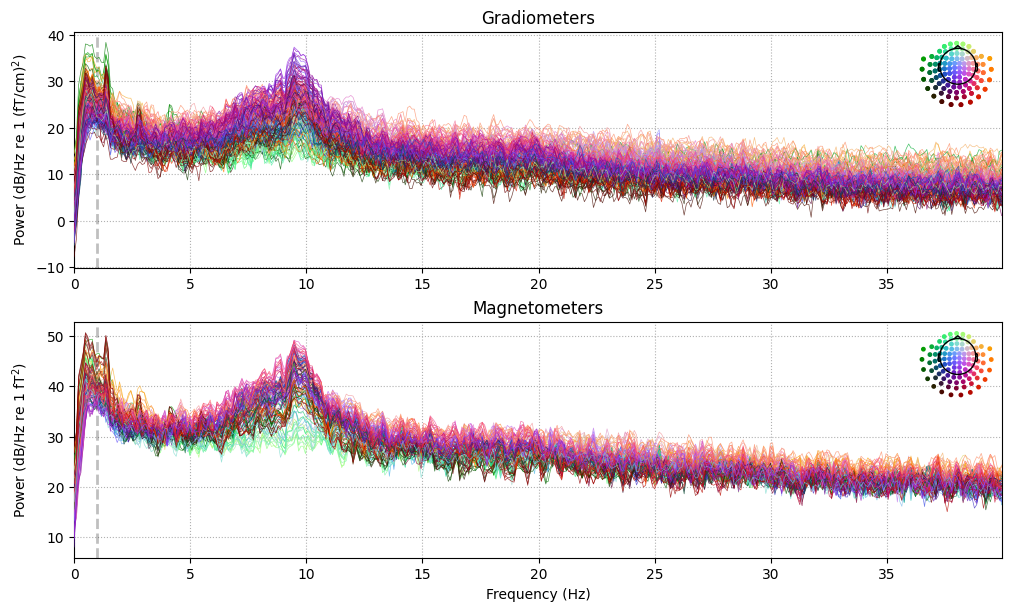

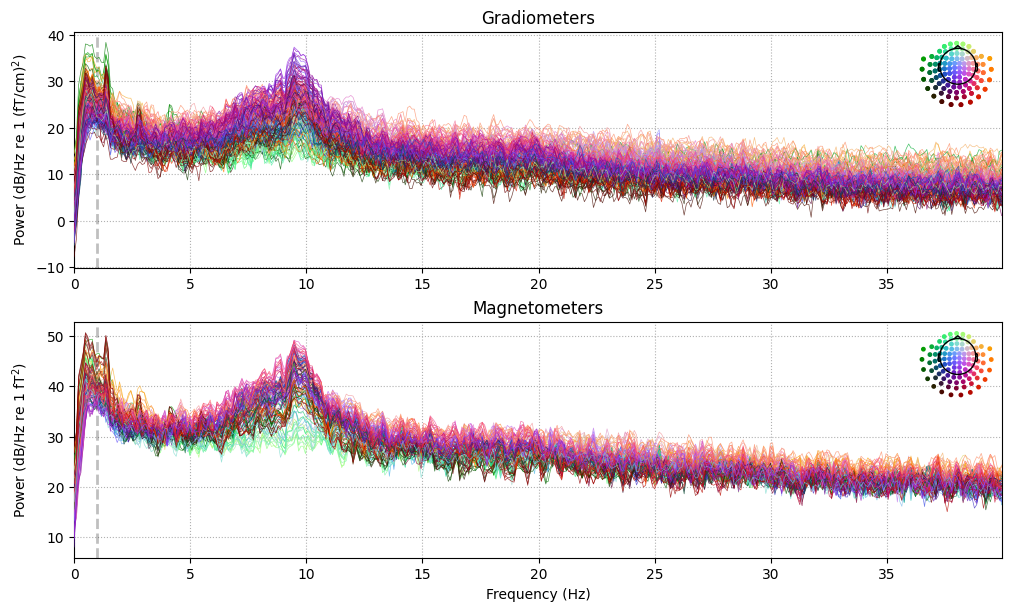

In [24]:
raw.compute_psd(fmax=40).plot()

Load Conectivity Matrix

Loaded PASP001_md1_NL_AR (Patients), shape: (68, 68)
Loaded PASP002_lr_AR_NL (Patients), shape: (68, 68)
Loaded PASP003_kb_NR_AL (Patients), shape: (68, 68)
Loaded PASP004_fm_NR_AL (Patients), shape: (68, 68)
Loaded PASP005_je_AL_NR (Patients), shape: (68, 68)
Loaded PASP006_ed (Patients), shape: (68, 68)
Loaded PASP007_kj_AR_NL (Patients), shape: (68, 68)
Loaded PASP008_gv_NR_AL (Patients), shape: (68, 68)
Skipping PASP009_kk_AR_NL (Patients), as it's in the avoid list.
Loaded PASP010_ka (Patients), shape: (68, 68)
Skipping PASP011_gc_NL_AR (Patients), as it's in the avoid list.
Loaded PASP012_ct_AR_NL (Patients), shape: (68, 68)
Loaded PASP013_yd_NL_AR (Patients), shape: (68, 68)
Loaded PASP014_bs_NL_AR (Patients), shape: (68, 68)
Loaded PASP015_da_NR_AL (Patients), shape: (68, 68)
Loaded PASP016_ca_NR_AL (Patients), shape: (68, 68)
Loaded PASP017_md2_AL_NR (Patients), shape: (68, 68)
Loaded PASP018_ht (Patients), shape: (68, 68)
Skipping PASP019_bj2_AR_NL (Patients), as it's in the 

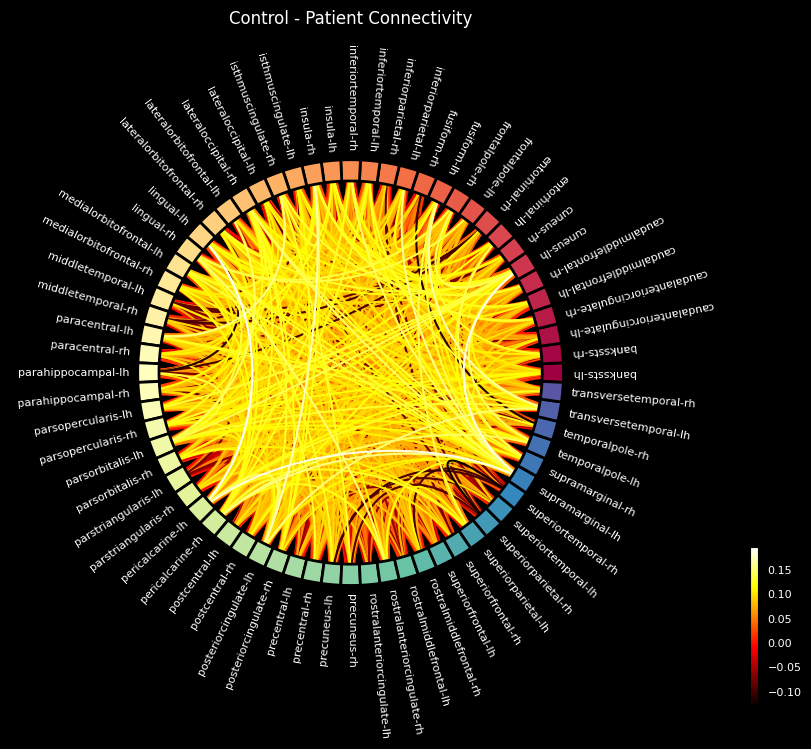

In [8]:
import numpy as np
import mne
import seaborn as sns
import matplotlib.pyplot as plt
labels_all_names = [label.name for label in labels_all]

# Set paths
subjects_dir = '/mnt/beegfs/malann/mne_data/MNE-fsaverage-data'
subject = "fsaverage"
src = f"{subjects_dir}/{subject}/bem/fsaverage-ico-5-src.fif"
bem = f"{subjects_dir}/{subject}/bem/fsaverage-5120-5120-5120-bem-sol.fif"

# Connectivity method
connectivity_method = 'wpli2_debiased'

def load_connectivity_data(subject_list, avoid_list, data_dir, group_name):
    """
    Loads connectivity matrices for a given group (patients or controls), avoiding specified subjects.

    Parameters:
    - subject_list: List of subject IDs
    - avoid_list: Set of subjects to exclude from analysis
    - data_dir: Directory containing connectivity matrices
    - group_name: String label for debugging (e.g., "Patients" or "Controls")

    Returns:
    - connectivity_array: Min-max Normalized Connectivity, NumPy array of shape (n_subjects, n_rois, n_rois)
    """
    connectivity_list = []
    
    for sub in subject_list:
        if sub in avoid_list:
            print(f"Skipping {sub} ({group_name}), as it's in the avoid list.")
            continue  # Skip this subject
        
        con_filename = f"{data_dir}{sub}_alpha_con_{connectivity_method}.npy"
        
        try:
            connectivity_matrix = np.load(con_filename)

            min_val = np.min(connectivity_matrix)
            max_val = np.max(connectivity_matrix)
            
            # Avoid division by zero if all values are the same
            if max_val == min_val:
                print(f"Warning: Zero variance connectivity for {sub} ({group_name}), replacing with zeros.")
                normalized_array = np.zeros_like(connectivity_matrix)
            else:
                normalized_array = (connectivity_matrix - min_val) / (max_val - min_val)
            # Mirror lower triangle to upper to ensure symmetry
            i_lower = np.tril_indices_from(normalized_array, k=-1)
            normalized_array[i_lower[1], i_lower[0]] = normalized_array[i_lower[0], i_lower[1]]
            
            connectivity_list.append(normalized_array)
            print(f"Loaded {sub} ({group_name}), shape: {connectivity_matrix.shape}")  # Debugging output

        except FileNotFoundError:
            print(f"Warning: Connectivity file not found for {sub} ({group_name})")

    if not connectivity_list:
        print(f"Error: No valid connectivity data found for {group_name}!")
        return None  # Handle this case later

    return np.array(connectivity_list)


# Load connectivity data for patients and controls, excluding subjects in avoid lists
patient_data_dir = "/mnt/beegfs/malann/Connectivity_Patient/"
control_data_dir = "/mnt/beegfs/malann/Connectivity_Camcan/"

patient_connectivity = load_connectivity_data(Patient_list, Patient_avoid, patient_data_dir, "Patients")
control_connectivity = load_connectivity_data(Control_list, Control_avoid, control_data_dir, "Controls")

# Ensure non-empty data before proceeding
if patient_connectivity is None or control_connectivity is None:
    raise ValueError("One or both connectivity datasets are empty! Check file paths, subject lists, and exclusion lists.")

# Compute average connectivity matrices
patient_avg_connectivity = np.mean(patient_connectivity, axis=0)
control_avg_connectivity = np.mean(control_connectivity, axis=0)

print("Final Patient Average Connectivity Matrix Shape:", patient_avg_connectivity.shape)
print("Final Control Average Connectivity Matrix Shape:", control_avg_connectivity.shape)


import mne_connectivity
import matplotlib.pyplot as plt

# Plot circular connectivity plot for controls
mne_connectivity.viz.plot_connectivity_circle(
    control_avg_connectivity-patient_avg_connectivity, 
    labels_all_names, 
    title="Control - Patient Connectivity", 
    colorbar=True, 
)
plt.show()

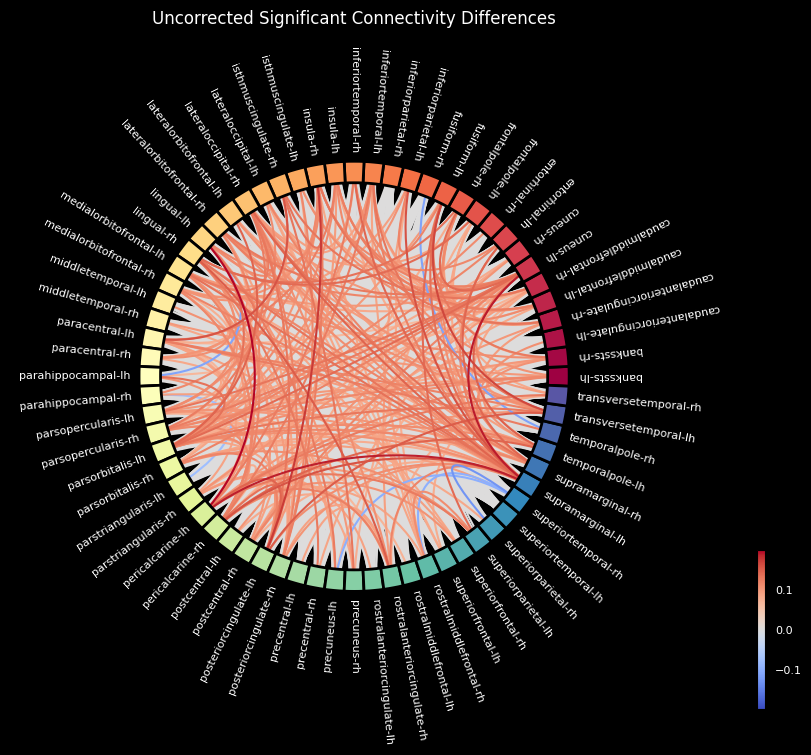

In [9]:
import numpy as np
import mne
from mne.stats import permutation_t_test
import matplotlib.pyplot as plt
import mne_connectivity
from scipy.stats import ttest_ind
from mne.stats import fdr_correction
# Assuming 'patient_connectivity' and 'control_connectivity' are already defined

# Flatten the matrices to perform group-wise statistical testing
patient_connectivity = np.array(patient_connectivity)
control_connectivity = np.array(control_connectivity)

patient_flat = patient_connectivity.reshape(patient_connectivity.shape[0], -1)  # Flatten into 2D (n_subjects, n_connections)
control_flat = control_connectivity.reshape(control_connectivity.shape[0], -1)

# Perform independent t-test for each connection
t_vals, p_vals = ttest_ind(control_flat, patient_flat, axis=0, equal_var=False)

# Apply FDR correction
_, p_vals_corrected = fdr_correction(p_vals, alpha=0.05)

# Reshape p-values
p_matrix = p_vals.reshape(patient_avg_connectivity.shape)
significant = p_matrix < 0.05

# Difference matrix
diff_matrix = control_flat.mean(axis=0).reshape(patient_avg_connectivity.shape) - patient_flat.mean(axis=0).reshape(patient_avg_connectivity.shape)
sig_diff = diff_matrix * significant

# Plot significant differences
mne_connectivity.viz.plot_connectivity_circle(
    sig_diff,
    labels_all_names,
    title="Uncorrected Significant Connectivity Differences",
    colorbar=True,
    colormap="coolwarm",
    vmin=-np.max(np.abs(sig_diff)),
    vmax=np.max(np.abs(sig_diff)),
)
plt.show()

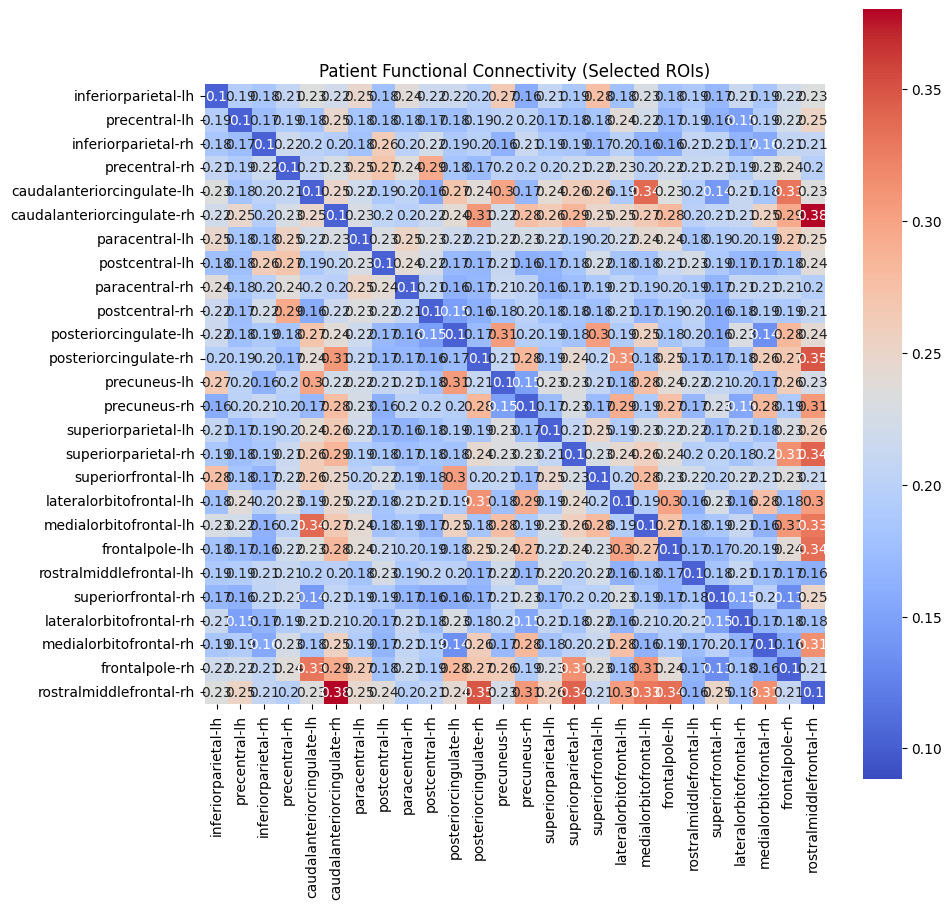

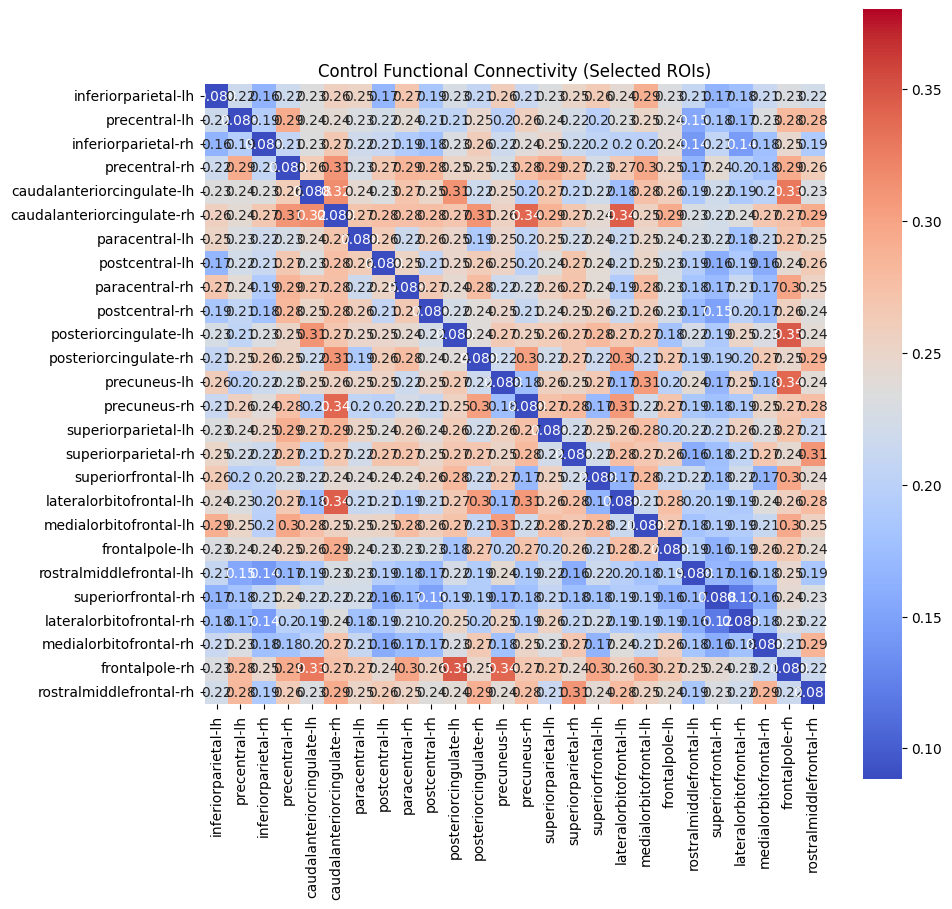

In [10]:
# Define label names for visualization
roi_labels = [ 'inferiorparietal-lh', 'precentral-lh', 'inferiorparietal-rh', 'precentral-rh', 'caudalanteriorcingulate-lh','caudalanteriorcingulate-rh',
    'paracentral-lh', 'postcentral-lh', 'paracentral-rh', 'postcentral-rh', 'posteriorcingulate-lh', 'posteriorcingulate-rh',
    'precuneus-lh', 'precuneus-rh', 'superiorparietal-lh', 'superiorparietal-rh',    
    'superiorfrontal-lh', 'lateralorbitofrontal-lh', 'medialorbitofrontal-lh', 'frontalpole-lh', 'rostralmiddlefrontal-lh',
             'superiorfrontal-rh', 'lateralorbitofrontal-rh', 'medialorbitofrontal-rh', 'frontalpole-rh', 'rostralmiddlefrontal-rh']


# Get indices of selected ROIs
roi_indices = [i for i, label in enumerate(labels_all) if label.name in roi_labels]

# Ensure selected ROIs exist in the dataset
if not roi_indices:
    raise ValueError("None of the specified ROIs were found in the annotation file!")

# Extract submatrix for selected ROIs
patient_submatrix = patient_avg_connectivity[np.ix_(roi_indices, roi_indices)]
control_submatrix = control_avg_connectivity[np.ix_(roi_indices, roi_indices)]

# Determine shared color scale
vmin = min(patient_submatrix.min(), control_submatrix.min())
vmax = max(patient_submatrix.max(), control_submatrix.max())

# Function to plot connectivity heatmaps
def plot_connectivity(matrix, title, vmin, vmax):
    plt.figure(figsize=(10, 10))
    sns.heatmap(matrix, annot=True, cmap='coolwarm', xticklabels=roi_labels, yticklabels=roi_labels, square=True, vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.show()

# Plot connectivity matrices with the same color scale
plot_connectivity(patient_submatrix, 'Patient Functional Connectivity (Selected ROIs)', vmin, vmax)
plot_connectivity(control_submatrix, 'Control Functional Connectivity (Selected ROIs)', vmin, vmax)


In [13]:
import pingouin

In [14]:
import numpy as np
import pandas as pd
from itertools import combinations

# Sample shape: (n_subjects, n_rois, n_rois)
n_subjects = 29
# Extract submatrices for each subject
patient_submatrices = patient_connectivity[:, roi_indices][:, :, roi_indices]  # shape (n_patients, n_rois, n_rois)
control_submatrices = control_connectivity[:, roi_indices][:, :, roi_indices]  # shape (n_controls, n_rois, n_rois)
roi_names = roi_labels  # list of 22 labels

# patient_data and control_data: shape = (29, 17, 17)
def matrix_to_long(data_matrix, group_label):
    subjects = []
    groups = []
    roi1_list = []
    roi2_list = []
    values = []

    for subj_idx in range(data_matrix.shape[0]):
        for i in range(len(roi_labels)):
            for j in range(i+1, len(roi_labels)):  # upper triangle only
                subjects.append(f"{group_label}_{subj_idx:02d}")
                groups.append(group_label)
                roi1_list.append(roi_labels[i])
                roi2_list.append(roi_labels[j])
                values.append(data_matrix[subj_idx, i, j])

    return pd.DataFrame({
        'subject': subjects,
        'group': groups,
        'ROI_1': roi1_list,
        'ROI_2': roi2_list,
        'connectivity': values
    })

# Create dataframes
df_patients = matrix_to_long(patient_submatrices, 'patient')
df_controls = matrix_to_long(control_submatrices, 'control')

# Combine
df_all = pd.concat([df_patients, df_controls], ignore_index=True)


import numpy as np
import pandas as pd
import pingouin as pg

# Assuming data preparation (df_all, roi_pairs, etc.) is already done as in the previous steps.

def compute_bayes_factor(x, y):
    """Compute Bayes Factor using pingouin's t-test with Bayes Factor."""
    # Perform t-test and compute BF10 directly
    ttest_res = pg.ttest(x=x, y=y, paired=False, correction=False, alternative='two-sided')
    bf10 = ttest_res['BF10'].values[0]  # Get Bayes Factor (BF10)
    t_stat = ttest_res['T'].values[0]   # Get T-statistic
    p_val = ttest_res['p-val'].values[0]  # Get p-value
    return bf10, t_stat, p_val

# Loop through ROI pairs and compute BF
bf_results = []
roi_pairs = df_all[['ROI_1', 'ROI_2']].drop_duplicates().values

for roi1, roi2 in roi_pairs:
    subset = df_all[(df_all['ROI_1'] == roi1) & (df_all['ROI_2'] == roi2)]

    x = subset[subset['group'] == 'patient']['connectivity'].values
    y = subset[subset['group'] == 'control']['connectivity'].values

    if len(x) > 1 and len(y) > 1:
        bf, t_val, p_val = compute_bayes_factor(x, y)
        bf_results.append({
            'ROI_1': roi1,
            'ROI_2': roi2,
            'BF10': bf,
            'T': t_val,
            'p-val': p_val
        })

# Convert results to DataFrame
df_bf = pd.DataFrame(bf_results)
df_bf
# Add a new column to determine which group has greater connectivity
df_bf['greater_group'] = np.where(df_bf['T'] > 0, 'patient', 'control')

# Display the updated DataFrame with the greater group column
df_bf


# Convert 'BF10' to numeric, coercing errors to NaN if necessary
df_bf['BF10'] = pd.to_numeric(df_bf['BF10'], errors='coerce')

# Now filter out ROI pairs with BF10 > 3
filtered_df_bf = df_bf[df_bf['BF10'] >= 3]

# Display the filtered results
filtered_df_bf


,ROI_1,ROI_2,BF10,T,p-val,greater_group
26,precentral-lh,precentral-rh,3.471,-2.513470,0.014754,control
174,paracentral-rh,posteriorcingulate-rh,4.735,-2.665650,0.009938,control
177,paracentral-rh,superiorparietal-lh,5.324,-2.721203,0.008573,control
317,superiorfrontal-rh,frontalpole-rh,4.579,-2.649640,0.010367,control


In [15]:
df_bf

,ROI_1,ROI_2,BF10,T,p-val,greater_group
0,inferiorparietal-lh,precentral-lh,0.307,-0.607732,0.545737,control
1,inferiorparietal-lh,inferiorparietal-rh,0.321,0.693450,0.490795,patient
2,inferiorparietal-lh,precentral-rh,0.268,-0.225708,0.822222,control
3,inferiorparietal-lh,caudalanteriorcingulate-lh,0.263,-0.019704,0.984347,control
4,inferiorparietal-lh,caudalanteriorcingulate-rh,0.353,-0.840912,0.403851,control
...,...,...,...,...,...,...
320,lateralorbitofrontal-rh,frontalpole-rh,0.632,-1.451481,0.152034,control
321,lateralorbitofrontal-rh,rostralmiddlefrontal-rh,0.437,-1.103173,0.274508,control
322,medialorbitofrontal-rh,frontalpole-rh,0.747,-1.584649,0.118484,control
323,medialorbitofrontal-rh,rostralmiddlefrontal-rh,0.292,0.500976,0.618284,patient


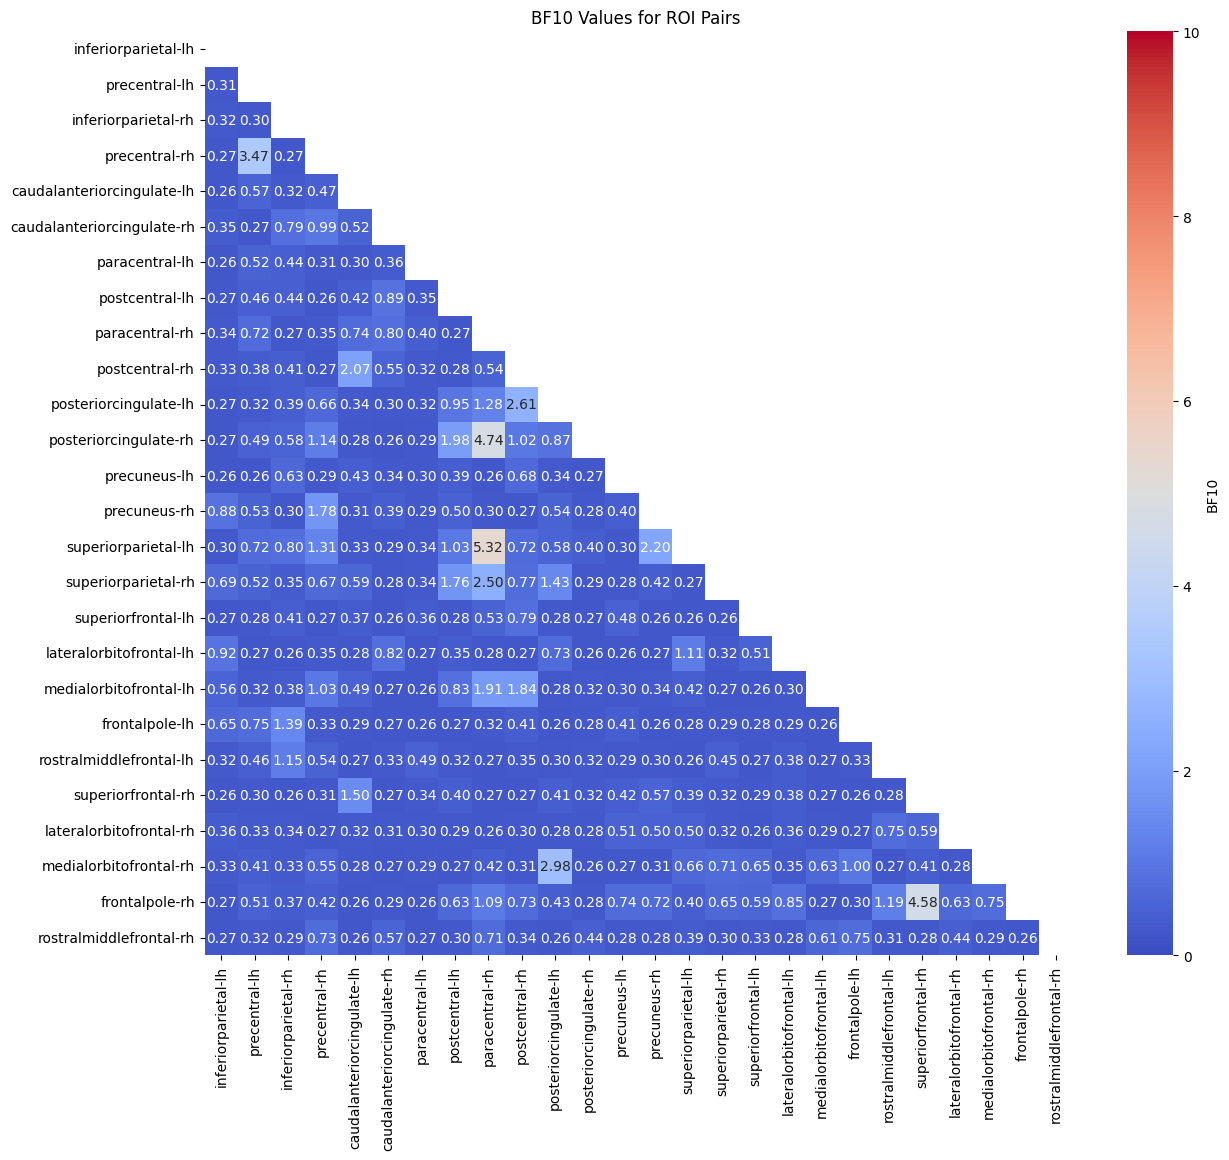

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create a matrix of BF values
bf_matrix = np.zeros((len(roi_labels), len(roi_labels)))

# Fill the matrix with the BF values from df_bf
for index, row in df_bf.iterrows():
    roi1_idx = roi_labels.index(row['ROI_1'])
    roi2_idx = roi_labels.index(row['ROI_2'])
    bf_matrix[roi1_idx, roi2_idx] = row['BF10']
    bf_matrix[roi2_idx, roi1_idx] = row['BF10']  # Since the matrix is symmetric

# Mask the upper triangle of the matrix
mask = np.triu(np.ones_like(bf_matrix, dtype=bool))

# Create the heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(bf_matrix, annot=True, cmap="coolwarm", fmt=".2f", mask=mask,
            xticklabels=roi_labels, yticklabels=roi_labels, cbar_kws={'label': 'BF10'},
            vmin=0, vmax=10)  # Adjust vmin and vmax as needed to control color scaling
plt.title("BF10 Values for ROI Pairs ")
plt.show()


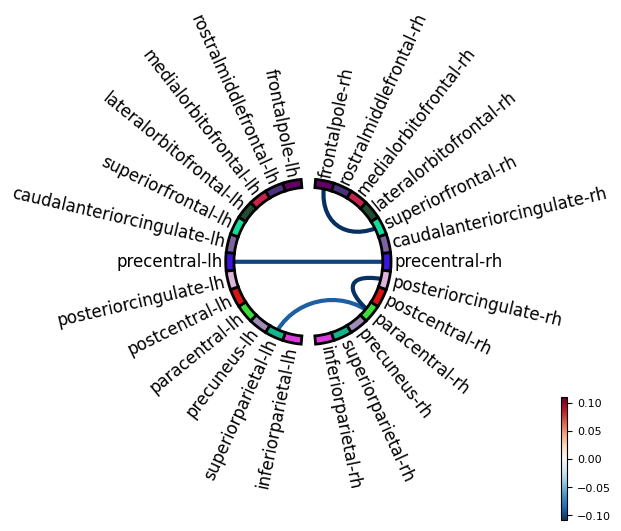

In [17]:
from mne_connectivity.viz import plot_connectivity_circle
import matplotlib.pyplot as plt


# Compute mean matrices and difference
mean_patient = np.mean(patient_submatrices, axis=0)
mean_control = np.mean(control_submatrices, axis=0)
difference_matrix = mean_patient - mean_control


# Only keep significant connections (lower triangle, symmetric)
significant_connections = np.full_like(difference_matrix, np.nan)

n_rois = len(roi_indices)

for i in range(n_rois):
    for j in range(i):
        if bf_matrix[i, j] > 3:
            val = difference_matrix[i, j]
            significant_connections[i, j] = val
            significant_connections[j, i] = val

# Set node colors
node_colors = ['#555555'] * len(roi_labels)
# Create a mapping from label name to color
label_color_dict = {label.name: label.color for label in labels_all}

# Ensure correct color order matching roi_labels
node_colors = [label_color_dict.get(name, 'gray') for name in roi_labels]


# First, we reorder the labels based on their location in the left hemi
label_names = roi_labels

lh_labels = [name for name in label_names if name.endswith("lh")]

# Get the y-location of the label
label_ypos = list()
for name in lh_labels:
    idx = labels_all_names.index(name)
    ypos = np.mean(labels_all[idx].pos[:, 1])
    label_ypos.append(ypos)

# Reorder the labels based on their location
lh_labels = [label for (yp, label) in sorted(zip(label_ypos, lh_labels))]

# For the right hemi
rh_labels = [name for name in label_names if name.endswith("rh")]

label_ypos_rh = list()
for name in rh_labels:
    idx = labels_all_names.index(name)
    ypos = np.mean(labels_all[idx].pos[:, 1])
    label_ypos_rh.append(ypos)

# Reorder the labels based on their location
rh_labels = [label for (yp, label) in sorted(zip(label_ypos_rh, rh_labels))]



# Save the plot order and create a circular layout
node_order = list()
node_order.extend(lh_labels[::-1])  # reverse the order
node_order.extend(rh_labels)

node_angles = circular_layout(
    label_names, node_order, start_pos=90, group_boundaries=[0, len(label_names) / 2]
)

non_nan_vals = significant_connections[~np.isnan(significant_connections)]
vlim = np.max(np.abs(non_nan_vals))

fig, ax = plt.subplots(figsize=(8, 8), facecolor="white", subplot_kw=dict(polar=True))

# Plot and unpack the returned tuple
fig, ax = plot_connectivity_circle(
    significant_connections,
    node_names=roi_labels, facecolor='white', textcolor='black',
    #title='Significant Connectivity Differences (Controls vs Patients)',
    colormap='RdBu_r',
    vmin=-vlim,
    vmax=+vlim,
    node_angles=node_angles,
    node_colors=node_colors,
    fontsize_names=12,
    linewidth=3,colorbar_size=0.2,
    padding=20.0,
    ax=ax,
)

# Set white background
fig.tight_layout()
plt.show()


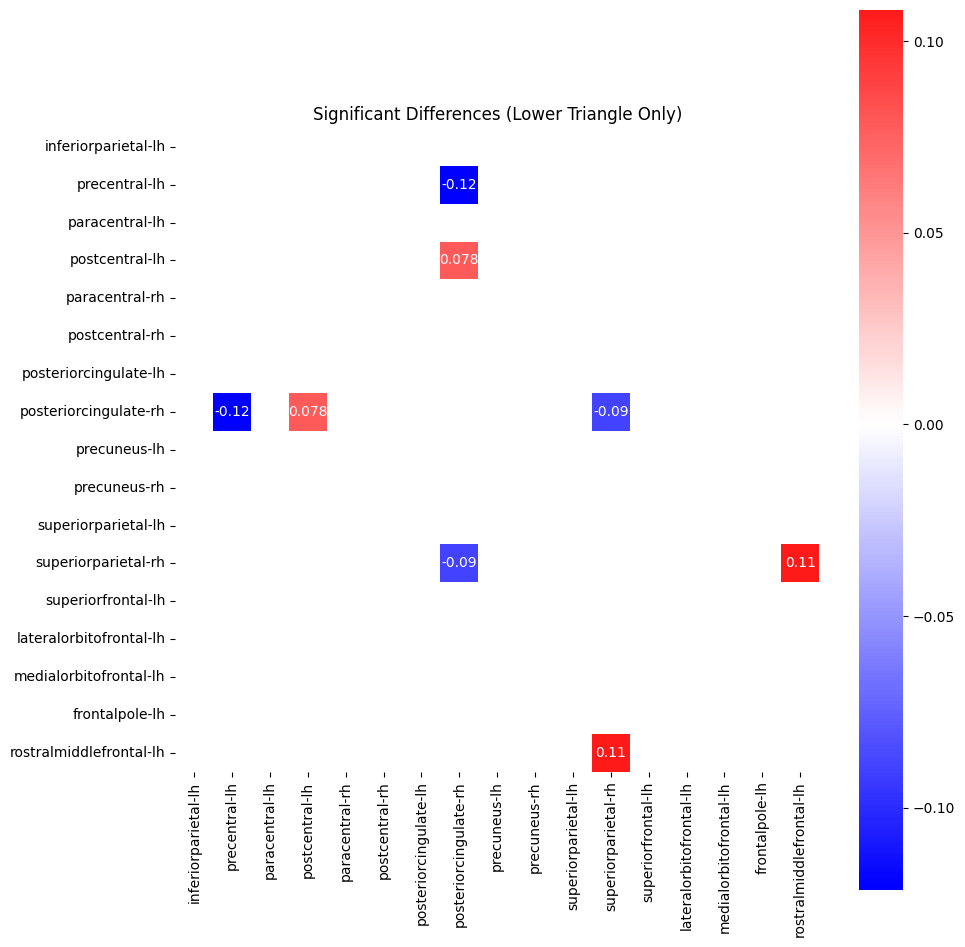

In [82]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import scipy.stats as stats
# Define label names for visualization
roi_labels = [ 'inferiorparietal-lh', 'precentral-lh', 
    'paracentral-lh', 'postcentral-lh', 'paracentral-rh', 'postcentral-rh', 'posteriorcingulate-lh', 'posteriorcingulate-rh',
    'precuneus-lh', 'precuneus-rh', 'superiorparietal-lh', 'superiorparietal-rh',    
    'superiorfrontal-lh', 'lateralorbitofrontal-lh', 'medialorbitofrontal-lh', 'frontalpole-lh', 'rostralmiddlefrontal-lh']

roi_indices = [i for i, label in enumerate(labels_all) if label.name in roi_labels]


# Define ROI mapping
roi_mapping = {
    'S1-L': ['postcentral-lh', 'paracentral-lh'],
    'S1-R': ['postcentral-rh', 'paracentral-rh'],
    'S2-L': ['inferiorparietal-lh', 'superiorparietal-lh'],
    'S2-R': ['superiorparietal-rh'],
    'PFC-L': ['superiorfrontal-lh', 'lateralorbitofrontal-lh', 'medialorbitofrontal-lh', 'frontalpole-lh', 'rostralmiddlefrontal-lh'],
    'DMN-L': ['posteriorcingulate-lh', 'precuneus-lh'],
    'DMN-R': ['posteriorcingulate-rh', 'precuneus-rh'],
    'M1-L': ['precentral-lh']
}


# Extract submatrices for each subject
patient_submatrices = patient_connectivity[:, roi_indices][:, :, roi_indices]  # shape (n_patients, n_rois, n_rois)
control_submatrices = control_connectivity[:, roi_indices][:, :, roi_indices]  # shape (n_controls, n_rois, n_rois)

n_rois = len(roi_indices)
p_values = np.full((n_rois, n_rois), np.nan)  # initialize with NaNs to ignore upper triangle & diagonal

# Mann-Whitney U test on lower triangle (excluding diagonal)
for i in range(n_rois):
    for j in range(n_rois):  
        p_values[i, j] = stats.mannwhitneyu(patient_submatrices[:, i, j], control_submatrices[:, i, j]).pvalue



# FDR correction per ROI on lower triangle
p_fdr = np.full_like(p_values, np.nan)

for i in range(n_rois):
    # Extract p-values from lower triangle only (excluding diagonal)
    mask = ~np.isnan(p_values[i, :])
    if np.sum(mask) > 0:
        _, p_corr, _, _ = multipletests(p_values[i, mask], method='fdr_bh')
        p_fdr[i, mask] = p_corr

# Symmetrize corrected p-values for plotting
p_fdr = np.fmin(p_fdr, p_fdr.T)  # keep the minimum corrected p-value between [i,j] and [j,i]

# Compute mean matrices and difference
mean_patient = np.mean(patient_submatrices, axis=0)
mean_control = np.mean(control_submatrices, axis=0)
difference_matrix = mean_patient - mean_control

# Mask non-significant differences (only keep lower triangle)
significant_mask = (p_values < 0.05)
masked_diff = np.where(significant_mask, difference_matrix, np.nan)

# Plot
plt.figure(figsize=(10, 10))
sns.heatmap(masked_diff, annot=True, cmap='bwr', xticklabels=roi_labels, yticklabels=roi_labels,
            square=True, center=0, mask=np.isnan(masked_diff))
plt.title("Significant Differences (Lower Triangle Only)")
plt.tight_layout()
plt.show()


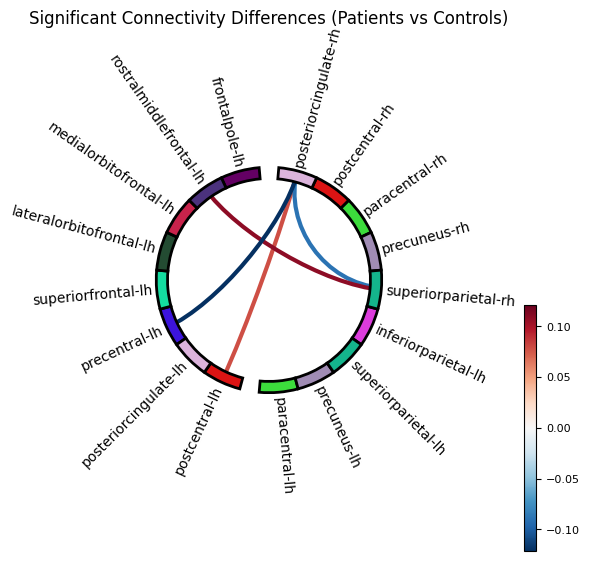

In [51]:
from mne_connectivity.viz import plot_connectivity_circle
import matplotlib.pyplot as plt

# Only keep significant connections (lower triangle, symmetric)
significant_connections = np.full_like(difference_matrix, np.nan)
for i in range(n_rois):
    for j in range(i):
        if p_values[i, j] < 0.05:
            val = difference_matrix[i, j]
            significant_connections[i, j] = val
            significant_connections[j, i] = val

# Set node colors
node_colors = ['#555555'] * len(roi_labels)
# Create a mapping from label name to color
label_color_dict = {label.name: label.color for label in labels_all}

# Ensure correct color order matching roi_labels
node_colors = [label_color_dict.get(name, 'gray') for name in roi_labels]


# First, we reorder the labels based on their location in the left hemi
label_names = roi_labels

lh_labels = [name for name in label_names if name.endswith("lh")]

# Get the y-location of the label
label_ypos = list()
for name in lh_labels:
    idx = labels_all_names.index(name)
    ypos = np.mean(labels_all[idx].pos[:, 1])
    label_ypos.append(ypos)

# Reorder the labels based on their location
lh_labels = [label for (yp, label) in sorted(zip(label_ypos, lh_labels))]

# For the right hemi
rh_labels = [name for name in label_names if name.endswith("rh")]

label_ypos_rh = list()
for name in rh_labels:
    idx = labels_all_names.index(name)
    ypos = np.mean(labels_all[idx].pos[:, 1])
    label_ypos_rh.append(ypos)

# Reorder the labels based on their location
rh_labels = [label for (yp, label) in sorted(zip(label_ypos_rh, rh_labels))]



# Save the plot order and create a circular layout
node_order = list()
node_order.extend(lh_labels[::-1])  # reverse the order
node_order.extend(rh_labels)

node_angles = circular_layout(
    label_names, node_order, start_pos=90, group_boundaries=[0, len(label_names) / 2]
)

non_nan_vals = significant_connections[~np.isnan(significant_connections)]
vlim = np.max(np.abs(non_nan_vals))

fig, ax = plt.subplots(figsize=(8, 8), facecolor="white", subplot_kw=dict(polar=True))

# Plot and unpack the returned tuple
fig, ax = plot_connectivity_circle(
    significant_connections,
    node_names=roi_labels, facecolor='white', textcolor='black',
    title='Significant Connectivity Differences (Patients vs Controls)',
    colormap='RdBu_r',
    vmin=-vlim,
    vmax=+vlim,
    node_angles=node_angles,
    node_colors=node_colors,
    fontsize_names=10,
    linewidth=3,colorbar_size=0.4,
    padding=12.0,
    ax=ax,
)

# Set white background
fig.tight_layout()
plt.show()


Compare Contol and paients

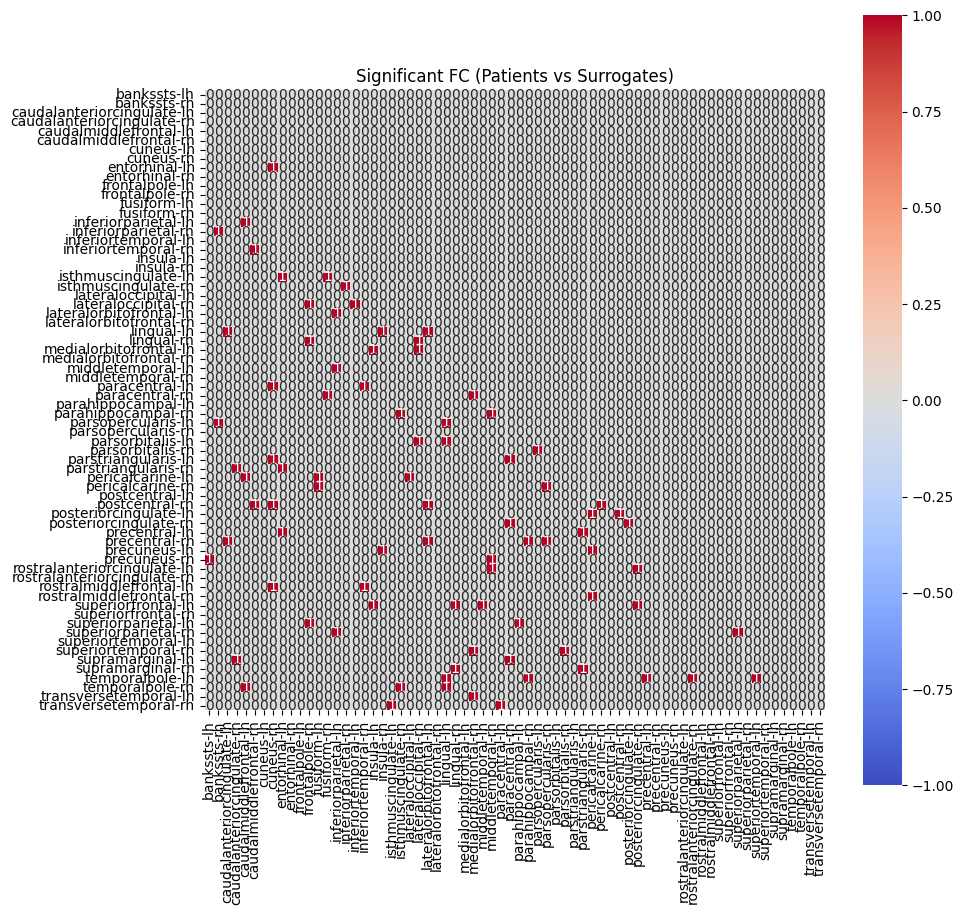

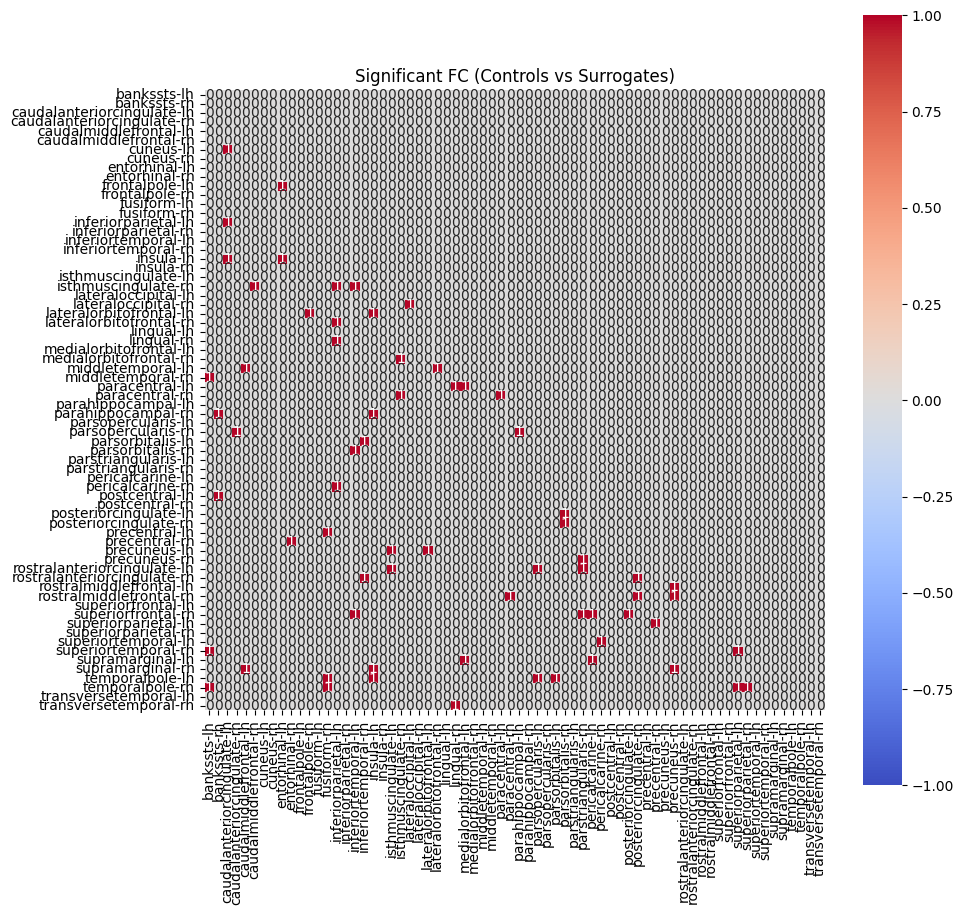

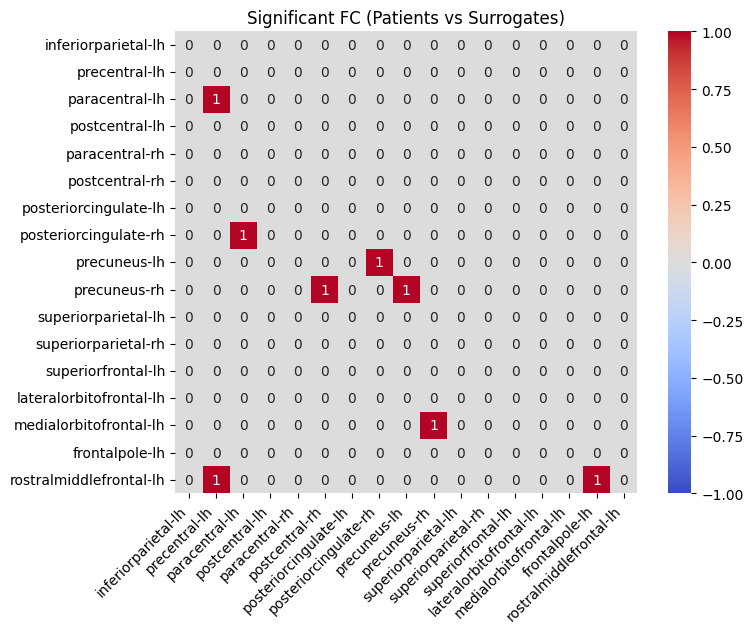

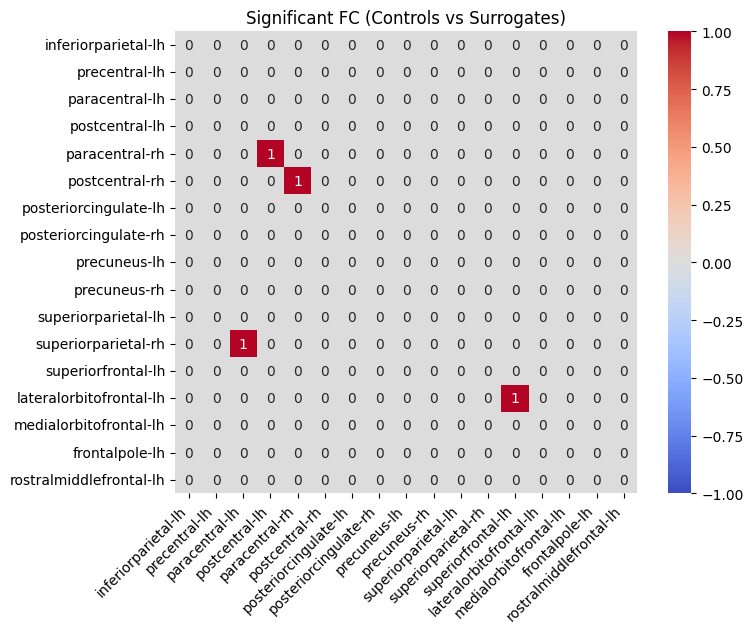

In [50]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import percentileofscore

# Function to create surrogate data by shuffling connectivity
def generate_surrogate_data(connectivity_matrices, n_permutations=1000):
    """
    Generates surrogate connectivity matrices by randomly permuting each subject's matrix.
    
    Parameters:
    - connectivity_matrices: NumPy array of shape (n_subjects, n_rois, n_rois)
    - n_permutations: Number of surrogate samples
    
    Returns:
    - surrogate_distribution: NumPy array of shape (n_permutations, n_rois, n_rois)
    """
    n_subjects, n_rois, _ = connectivity_matrices.shape
    surrogate_distribution = np.zeros((n_permutations, n_rois, n_rois))

    for i in range(n_permutations):
        # Shuffle along subject axis (breaking true FC structure)
        shuffled_indices = np.random.permutation(n_subjects)
        surrogate_distribution[i] = np.mean(connectivity_matrices[shuffled_indices], axis=0)

    return surrogate_distribution

# Generate surrogate data for patients and controls
n_permutations = 10000  # Number of bootstraps
patient_surrogates = generate_surrogate_data(patient_connectivity, n_permutations)
control_surrogates = generate_surrogate_data(control_connectivity, n_permutations)

# Compute percentile-based significance
def compute_significance(true_fc, surrogate_distribution):
    """
    Compares true functional connectivity against a surrogate distribution.

    Returns:
    - significance_matrix: 1 if significantly higher than 95th percentile, -1 if lower than 5th percentile, else 0
    """
    significance_matrix = np.zeros_like(true_fc)

    for i in range(true_fc.shape[0]):
        for j in range(true_fc.shape[1]):
            percentile = percentileofscore(surrogate_distribution[:, i, j], true_fc[i, j])
            
            if percentile >= 95:  # Significantly higher
                significance_matrix[i, j] = 1
            elif percentile <= 0:  # Significantly lower
                significance_matrix[i, j] = -1

    return significance_matrix

# Compute significance for patients and controls
patient_significance = compute_significance(patient_avg_connectivity, patient_surrogates)
control_significance = compute_significance(control_avg_connectivity, control_surrogates)

# Plot significant connections
def plot_connectivity(matrix, title, vmin, vmax):
    plt.figure(figsize=(10, 10))
    sns.heatmap(matrix, annot=True, cmap='coolwarm', xticklabels=labels_all_names, yticklabels=labels_all_names, square=True, vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.show()


plot_connectivity(patient_significance, "Significant FC (Patients vs Surrogates)", vmin=-1, vmax=1)
plot_connectivity(control_significance, "Significant FC (Controls vs Surrogates)", vmin=-1, vmax=1)


# Extract submatrices for selected ROIs
patient_significance_submatrix = patient_significance[np.ix_(roi_indices, roi_indices)]
control_significance_submatrix = control_significance[np.ix_(roi_indices, roi_indices)]

# Function to plot connectivity heatmaps for selected ROIs
def plot_connectivity(matrix, title, vmin, vmax, roi_labels):
    plt.figure(figsize=(8, 6))  # Adjust size for clarity
    sns.heatmap(matrix, annot=True, cmap='coolwarm', xticklabels=roi_labels, yticklabels=roi_labels, square=True, vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
    plt.yticks(rotation=0)
    plt.show()

# Plot significant connections for selected ROIs
plot_connectivity(patient_significance_submatrix, "Significant FC (Patients vs Surrogates)", vmin=-1, vmax=1, roi_labels=roi_labels)
plot_connectivity(control_significance_submatrix, "Significant FC (Controls vs Surrogates)", vmin=-1, vmax=1, roi_labels=roi_labels)


In [132]:
# Compute raw differences and p-values
results = []
for i in range(n_rois):
    for j in range(n_rois):
        if i != j:
            stat, pval = stats.mannwhitneyu(patient_submatrices[:, i, j], control_submatrices[:, i, j])
            mean_diff = patient_submatrices[:, i, j].mean() - control_submatrices[:, i, j].mean()
            results.append((i, j, pval, mean_diff))

# Sort by uncorrected p-value
sorted_results = sorted(results, key=lambda x: x[2])
print("Top 10 effects (uncorrected):")
for i, j, pval, diff in sorted_results[:10]:
    print(f"{roi_labels[i]} ↔ {roi_labels[j]} | p = {pval:.4f}, Δ = {diff:.4f}")


Top 10 effects (uncorrected):
posteriorcingulate-rh ↔ postcentral-lh | p = 0.0153, Δ = 0.0780
posteriorcingulate-rh ↔ precentral-lh | p = 0.0189, Δ = -0.1214
superiorparietal-rh ↔ posteriorcingulate-rh | p = 0.0197, Δ = -0.0896
rostralmiddlefrontal-lh ↔ superiorparietal-rh | p = 0.0386, Δ = 0.1081
frontalpole-lh ↔ postcentral-lh | p = 0.0558, Δ = 0.0642
medialorbitofrontal-lh ↔ postcentral-lh | p = 0.0642, Δ = 0.0551
postcentral-rh ↔ paracentral-rh | p = 0.0930, Δ = -0.0630
superiorparietal-lh ↔ precentral-lh | p = 0.0961, Δ = -0.0762
posteriorcingulate-rh ↔ paracentral-rh | p = 0.1355, Δ = -0.0637
superiorfrontal-lh ↔ superiorparietal-rh | p = 0.1396, Δ = -0.0725


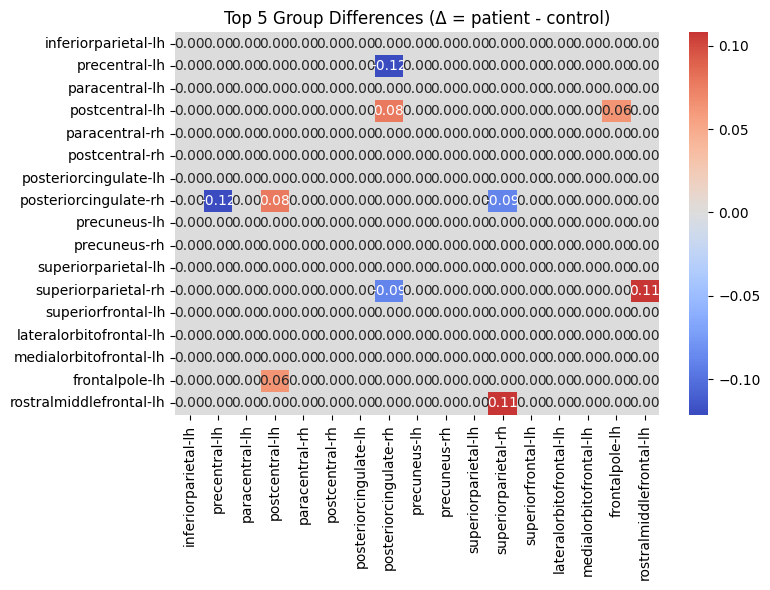

In [133]:
# Create an empty matrix for top effects
top_effects_matrix = np.zeros((n_rois, n_rois))

# Fill in top N uncorrected significant values
top_n = 5
for i, j, pval, diff in sorted_results[:top_n]:
    top_effects_matrix[i, j] = diff
    top_effects_matrix[j, i] = diff  # symmetric

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(top_effects_matrix, xticklabels=roi_labels, yticklabels=roi_labels, cmap='coolwarm', center=0, annot=True, fmt=".2f")
plt.title(f"Top {top_n} Group Differences (Δ = patient - control)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


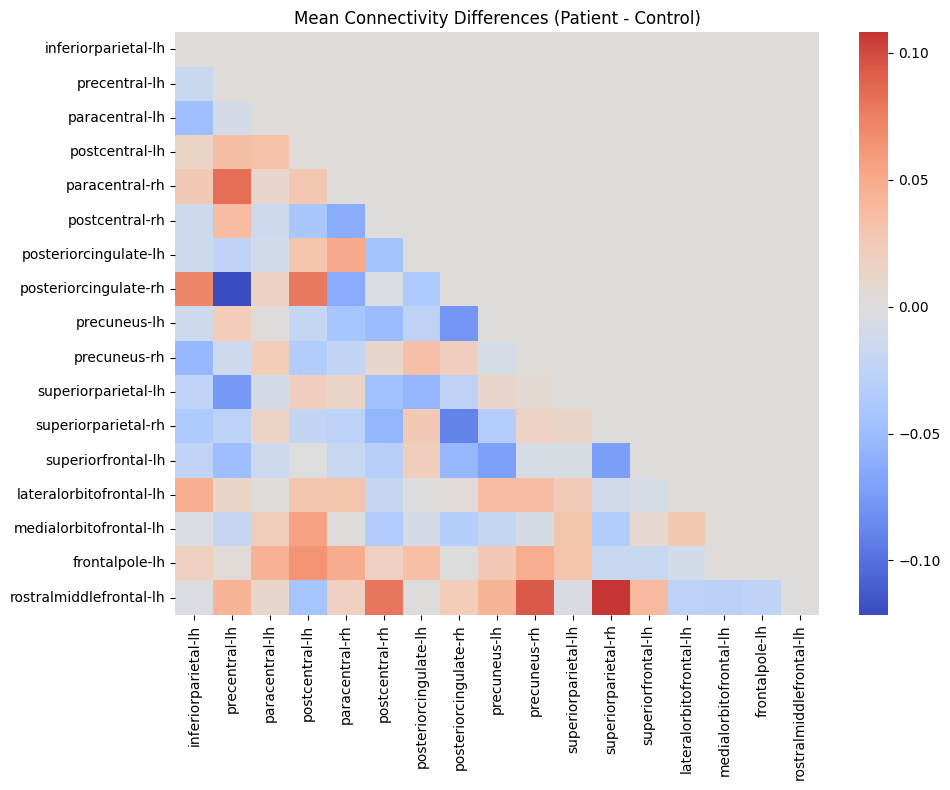

In [57]:
mean_diff_matrix = patient_submatrices.mean(axis=0) - control_submatrices.mean(axis=0)

plt.figure(figsize=(10, 8))
sns.heatmap(mean_diff_matrix, xticklabels=roi_labels, yticklabels=roi_labels, cmap='coolwarm', center=0, annot=False)
plt.title("Mean Connectivity Differences (Patient - Control)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [194]:
fsaverage

{'area_left': '/home/malann/.local/lib/python3.10/site-packages/nilearn/datasets/data/fsaverage5/area_left.gii.gz',
 'area_right': '/home/malann/.local/lib/python3.10/site-packages/nilearn/datasets/data/fsaverage5/area_right.gii.gz',
 'curv_left': '/home/malann/.local/lib/python3.10/site-packages/nilearn/datasets/data/fsaverage5/curv_left.gii.gz',
 'curv_right': '/home/malann/.local/lib/python3.10/site-packages/nilearn/datasets/data/fsaverage5/curv_right.gii.gz',
 'flat_left': '/home/malann/.local/lib/python3.10/site-packages/nilearn/datasets/data/fsaverage5/flat_left.gii.gz',
 'flat_right': '/home/malann/.local/lib/python3.10/site-packages/nilearn/datasets/data/fsaverage5/flat_right.gii.gz',
 'infl_left': '/home/malann/.local/lib/python3.10/site-packages/nilearn/datasets/data/fsaverage5/infl_left.gii.gz',
 'infl_right': '/home/malann/.local/lib/python3.10/site-packages/nilearn/datasets/data/fsaverage5/infl_right.gii.gz',
 'pial_left': '/home/malann/.local/lib/python3.10/site-packages/

In [201]:
import numpy as np
from netplotbrain import NetPlotBrain

# Connectivity matrix (replace with your actual data)
connectivity_matrix = np.random.rand(5, 5)  # example, replace with your connectivity data

# Coordinates for each ROI in MNI space (replace with actual coordinates)
roi_coords = np.random.rand(5, 3)  # example coordinates (x, y, z in MNI)

# Initialize NetPlotBrain with your connectivity data
brain_plot = NetPlotBrain(connectivity_matrix, roi_coords)

# Visualize the connectivity on a brain
brain_plot.show()


ImportError: cannot import name 'TypeAliasType' from 'typing_extensions' (/cm/shared/apps/python/gpu/3.10.6/lib/python3.10/site-packages/typing_extensions.py)

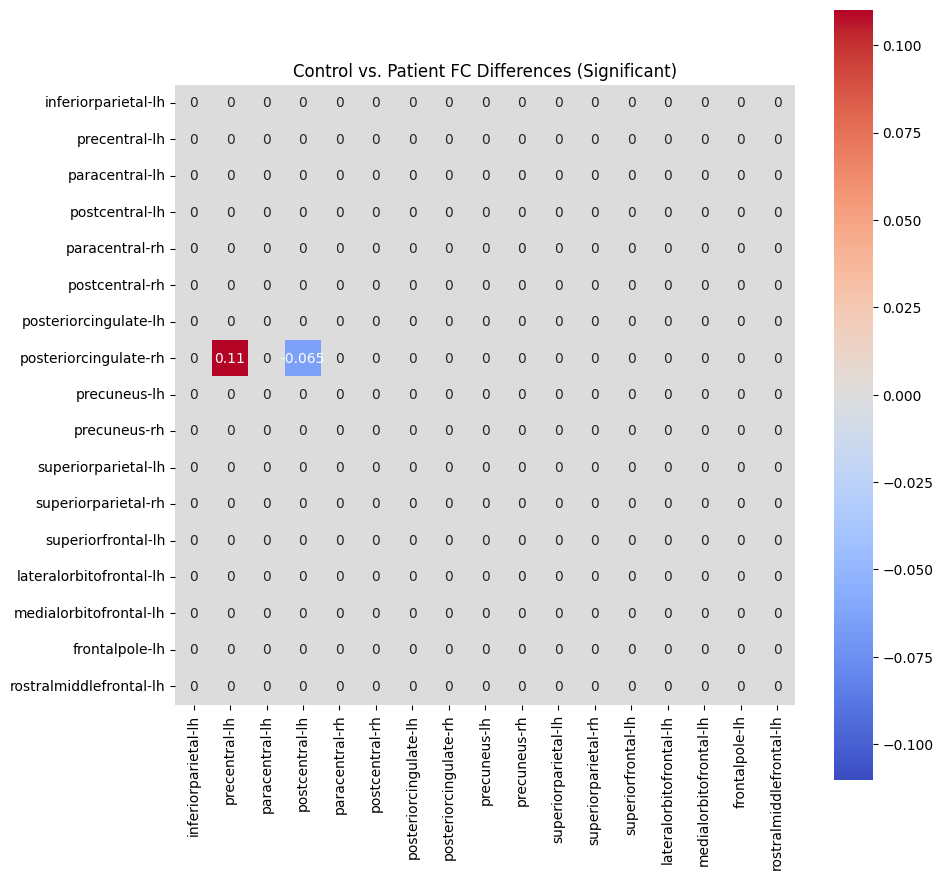

In [25]:
from scipy.stats import ttest_ind
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming patient_connectivity and control_connectivity are already loaded

patient_sub = patient_connectivity
control_sub = control_connectivity

# Compute independent t-tests for each connection across all ROIs
t_values, p_values = ttest_ind(control_sub, patient_sub, axis=0, equal_var=False)

# Apply significance threshold (e.g., p < 0.05)
significance_mask = p_values < 0.05

# Create difference matrix (mean patient - mean control) across all ROIs
difference_matrix = np.mean(control_sub , axis=0) - np.mean(patient_sub, axis=0)

# Mask non-significant results
difference_matrix[~significance_mask] = 0

# Now, focus only on the submatrix for the ROIs of interest
# Define the indices for roi_labels (you should have these indices ready)
roi_indices = [i for i, label in enumerate(labels_all_names) if label in roi_labels]  # Assuming 'labels_all_names' holds all label names

# Extract submatrix for selected ROIs
selected_difference_matrix = difference_matrix[np.ix_(roi_indices, roi_indices)]

# Define shared color scale
vmin = -np.max(np.abs(selected_difference_matrix))
vmax = np.max(np.abs(selected_difference_matrix))

# Plot the significant differences for the selected ROIs
def plot_connectivity(matrix, title, vmin, vmax, roi_labels):
    plt.figure(figsize=(10, 10))
    sns.heatmap(matrix, annot=True, cmap='coolwarm', xticklabels=roi_labels, yticklabels=roi_labels, square=True, vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.show()

# Plot the difference matrix for the selected ROIs
plot_connectivity(selected_difference_matrix, 'Control vs. Patient FC Differences (Significant)', vmin, vmax, roi_labels)


In [26]:
p_values

array([[0.47328982, 0.47328982, 0.47328982, ..., 0.47328982, 0.47328982,
        0.47328982],
       [0.25677275, 0.47328982, 0.47328982, ..., 0.47328982, 0.47328982,
        0.47328982],
       [0.67930866, 0.48555811, 0.47328982, ..., 0.47328982, 0.47328982,
        0.47328982],
       ...,
       [0.35382568, 0.61018721, 0.60210867, ..., 0.47328982, 0.47328982,
        0.47328982],
       [0.48070392, 0.56150287, 0.43295545, ..., 0.50482602, 0.47328982,
        0.47328982],
       [0.02682031, 0.91224962, 0.82054324, ..., 0.9070863 , 0.30992936,
        0.47328982]])

stat_fun(H1): min=-3.1143274025729366 max=3.2718831543848963
Running initial clustering …
Found 0 clusters


/tmp/ipykernel_3799681/1695254872.py:28: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(
/tmp/ipykernel_3799681/1695254872.py:28: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  T_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(


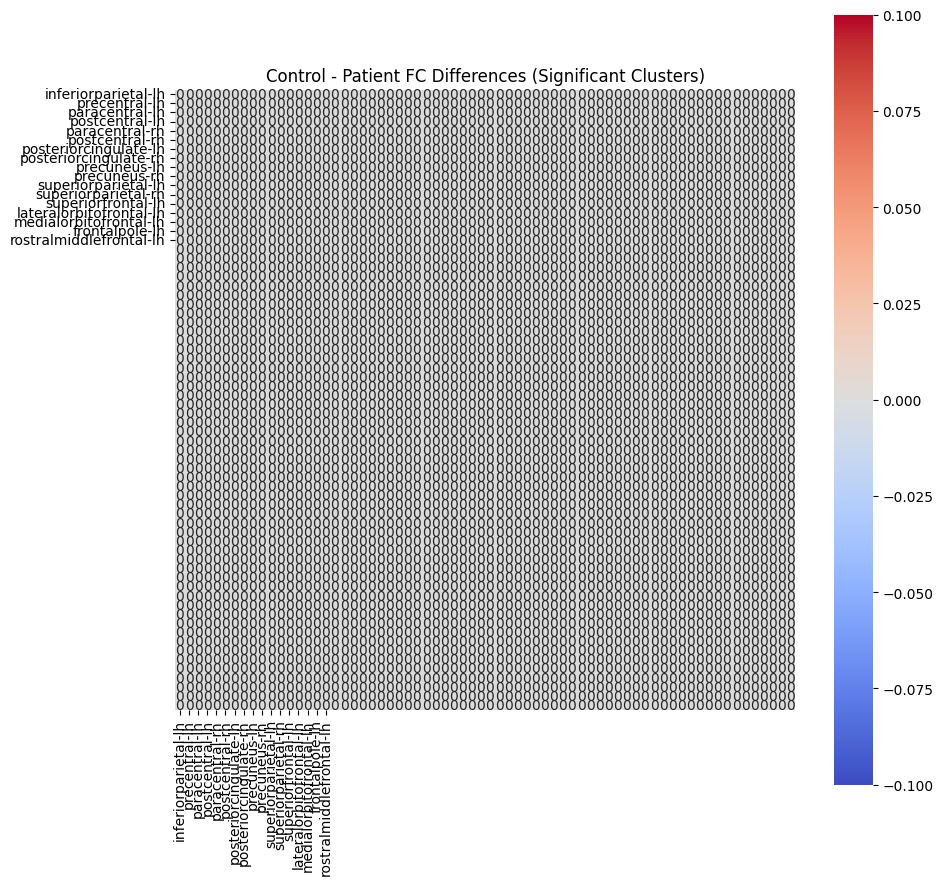

In [27]:
import numpy as np
import mne
from scipy.stats import ttest_ind
from mne.stats import permutation_cluster_test
import seaborn as sns
import matplotlib.pyplot as plt
from functools import partial
from scipy import stats

# Ensure data is correctly shaped: (n_subjects, n_rois, n_rois)
patient_data = np.array(patient_connectivity)  # Shape (n_patients, n_rois, n_rois)
control_data = np.array(control_connectivity)  # Shape (n_controls, n_rois, n_rois)

X = [patient_data, control_data]

# Group labels (0 = patients, 1 = controls)
n_patients = len(patient_data)
n_controls = len(control_data)
n_rois = control_data.shape[1]

# Define statistical function
stat_fun = partial(mne.stats.ttest_ind_no_p, sigma=1e-3)

# Compute threshold for t-distribution
df = n_patients + n_controls - 2  # Correct degrees of freedom
t_threshold = -stats.t.ppf(0.001 / 2, df)  # Two-tailed test

T_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(
    X, n_permutations=10000, tail=0, out_type='mask', seed=42, threshold=t_threshold, stat_fun=stat_fun
)

# Reshape results back into ROI x ROI matrices
T_obs_matrix = T_obs.reshape(n_rois, n_rois)  # Observed T-values
significance_mask = np.zeros_like(T_obs_matrix, dtype=bool)

# Apply significance mask to highlight significant clusters
for i, p_val in enumerate(cluster_p_values):
    if p_val < 0.1:  # Set significance threshold
        significance_mask[clusters[i]] = True

# Create masked difference matrix (set non-significant values to 0)
difference_matrix = T_obs_matrix.copy()
difference_matrix[~significance_mask] = 0  # Mask non-significant results

# Determine shared color scale
vmin = -np.max(np.abs(difference_matrix))
vmax = np.max(np.abs(difference_matrix))

# Plot results
def plot_connectivity(matrix, title, vmin, vmax, roi_labels):
    plt.figure(figsize=(10, 10))
    sns.heatmap(matrix, annot=True, cmap='coolwarm', xticklabels=roi_labels, yticklabels=roi_labels, square=True, vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.show()

# Plot significant differences
plot_connectivity(difference_matrix, 'Control - Patient FC Differences (Significant Clusters)', vmin, vmax, roi_labels)


In [ ]:
# for 'superiorfrontal-lh' and "superiorfrontal-rh", "superiorparietal-lh", "superiorparietal-rh"]
SFL_SFR_p=[]
SFL_SFR_c=[]

SFL_SPL_p=[]
SFL_SPL_c=[]

SFL_SPR_p=[]
SFL_SPR_c=[]

# "superiorfrontal-rh" with other three
SFR_SFL_p=[]
SFR_SFL_c=[]

SFR_SPL_p=[]
SFR_SPL_c=[]

SFR_SPR_p=[]
SFR_SPR_c=[]

for c_con, p_con in zip(con_list_C,con_list_P):
    SFL_SFR_p.append(p_con[1][0])
    SFL_SFR_c.append(c_con[1][0])
    
    SFL_SPL_p.append(p_con[2][0])
    SFL_SPL_c.append(c_con[2][0])

    SFL_SPR_p.append(p_con[3][0])
    SFL_SPR_c.append(c_con[3][0])

  

    SFR_SFL_p.append(p_con[1][0])
    SFR_SFL_c.append(c_con[1][0])
    
    SFR_SPL_p.append(p_con[2][1])
    SFR_SPL_c.append(c_con[2][1])

    SFR_SPR_p.append(p_con[3][1])
    SFR_SPR_c.append(c_con[3][1])


In [ ]:
plt.boxplot([SFL_SFR_p,SFL_SFR_c, SFL_SPL_p,SFL_SPL_c,SFL_SPR_p,SFL_SPR_c, SFR_SPL_p,SFR_SPL_c,SFR_SPR_p,SFR_SPR_c],patch_artist = True,widths =0.5,
                notch ='False')


In [ ]:
pval = scipy.stats.ttest_ind(SFR_SPR_p,SFR_SPR_c)
pval

In [ ]:
plt.boxplot([SFL_SPL_p,SFL_SPL_c, SFR_SPR_p,SFR_SPR_c],patch_artist = True,widths =0.5,
                notch ='False')


In [ ]:
SFL_SPL_p = np.array(SFL_SPL_p)
PR = np.array(list(pain_rating.values()))

plt.scatter(SFL_SPL_p,PR)

#obtain m (slope) and b(intercept) of linear regression line
m, b = np.polyfit(SFL_SPL_p,PR, 1)

t, p = scipy.stats.spearmanr(SFL_SPL_p,PR)

#add linear regression line to scatterplot 
plt.plot(SFL_SPL_p, m*SFL_SPL_p+b)

plt.xlabel('Functional Connectivity: SFL-SPL')
plt.ylabel('Pain Ratings')
plt.text(0.4,7,f'pvalue = {round(p,4)}')

In [ ]:
SFL_SPL_p = np.array(SFR_SPR_p)
PR = np.array(list(pain_rating.values()))

plt.scatter(SFL_SPL_p,PR)

#obtain m (slope) and b(intercept) of linear regression line
m, b = np.polyfit(SFL_SPL_p,PR, 1)

t, p = scipy.stats.spearmanr(SFL_SPL_p,PR)

#add linear regression line to scatterplot 
plt.plot(SFL_SPL_p, m*SFL_SPL_p+b)

plt.xlabel('Functional Connectivity: SFR-SPR')
plt.ylabel('Pain Ratings')
plt.text(0.22,7,f'pvalue = {round(p,4)}')